<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Qubit_Decoherence_Based_on_7_Classifications_Illustrative_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!uv pip install qutip matplotlib

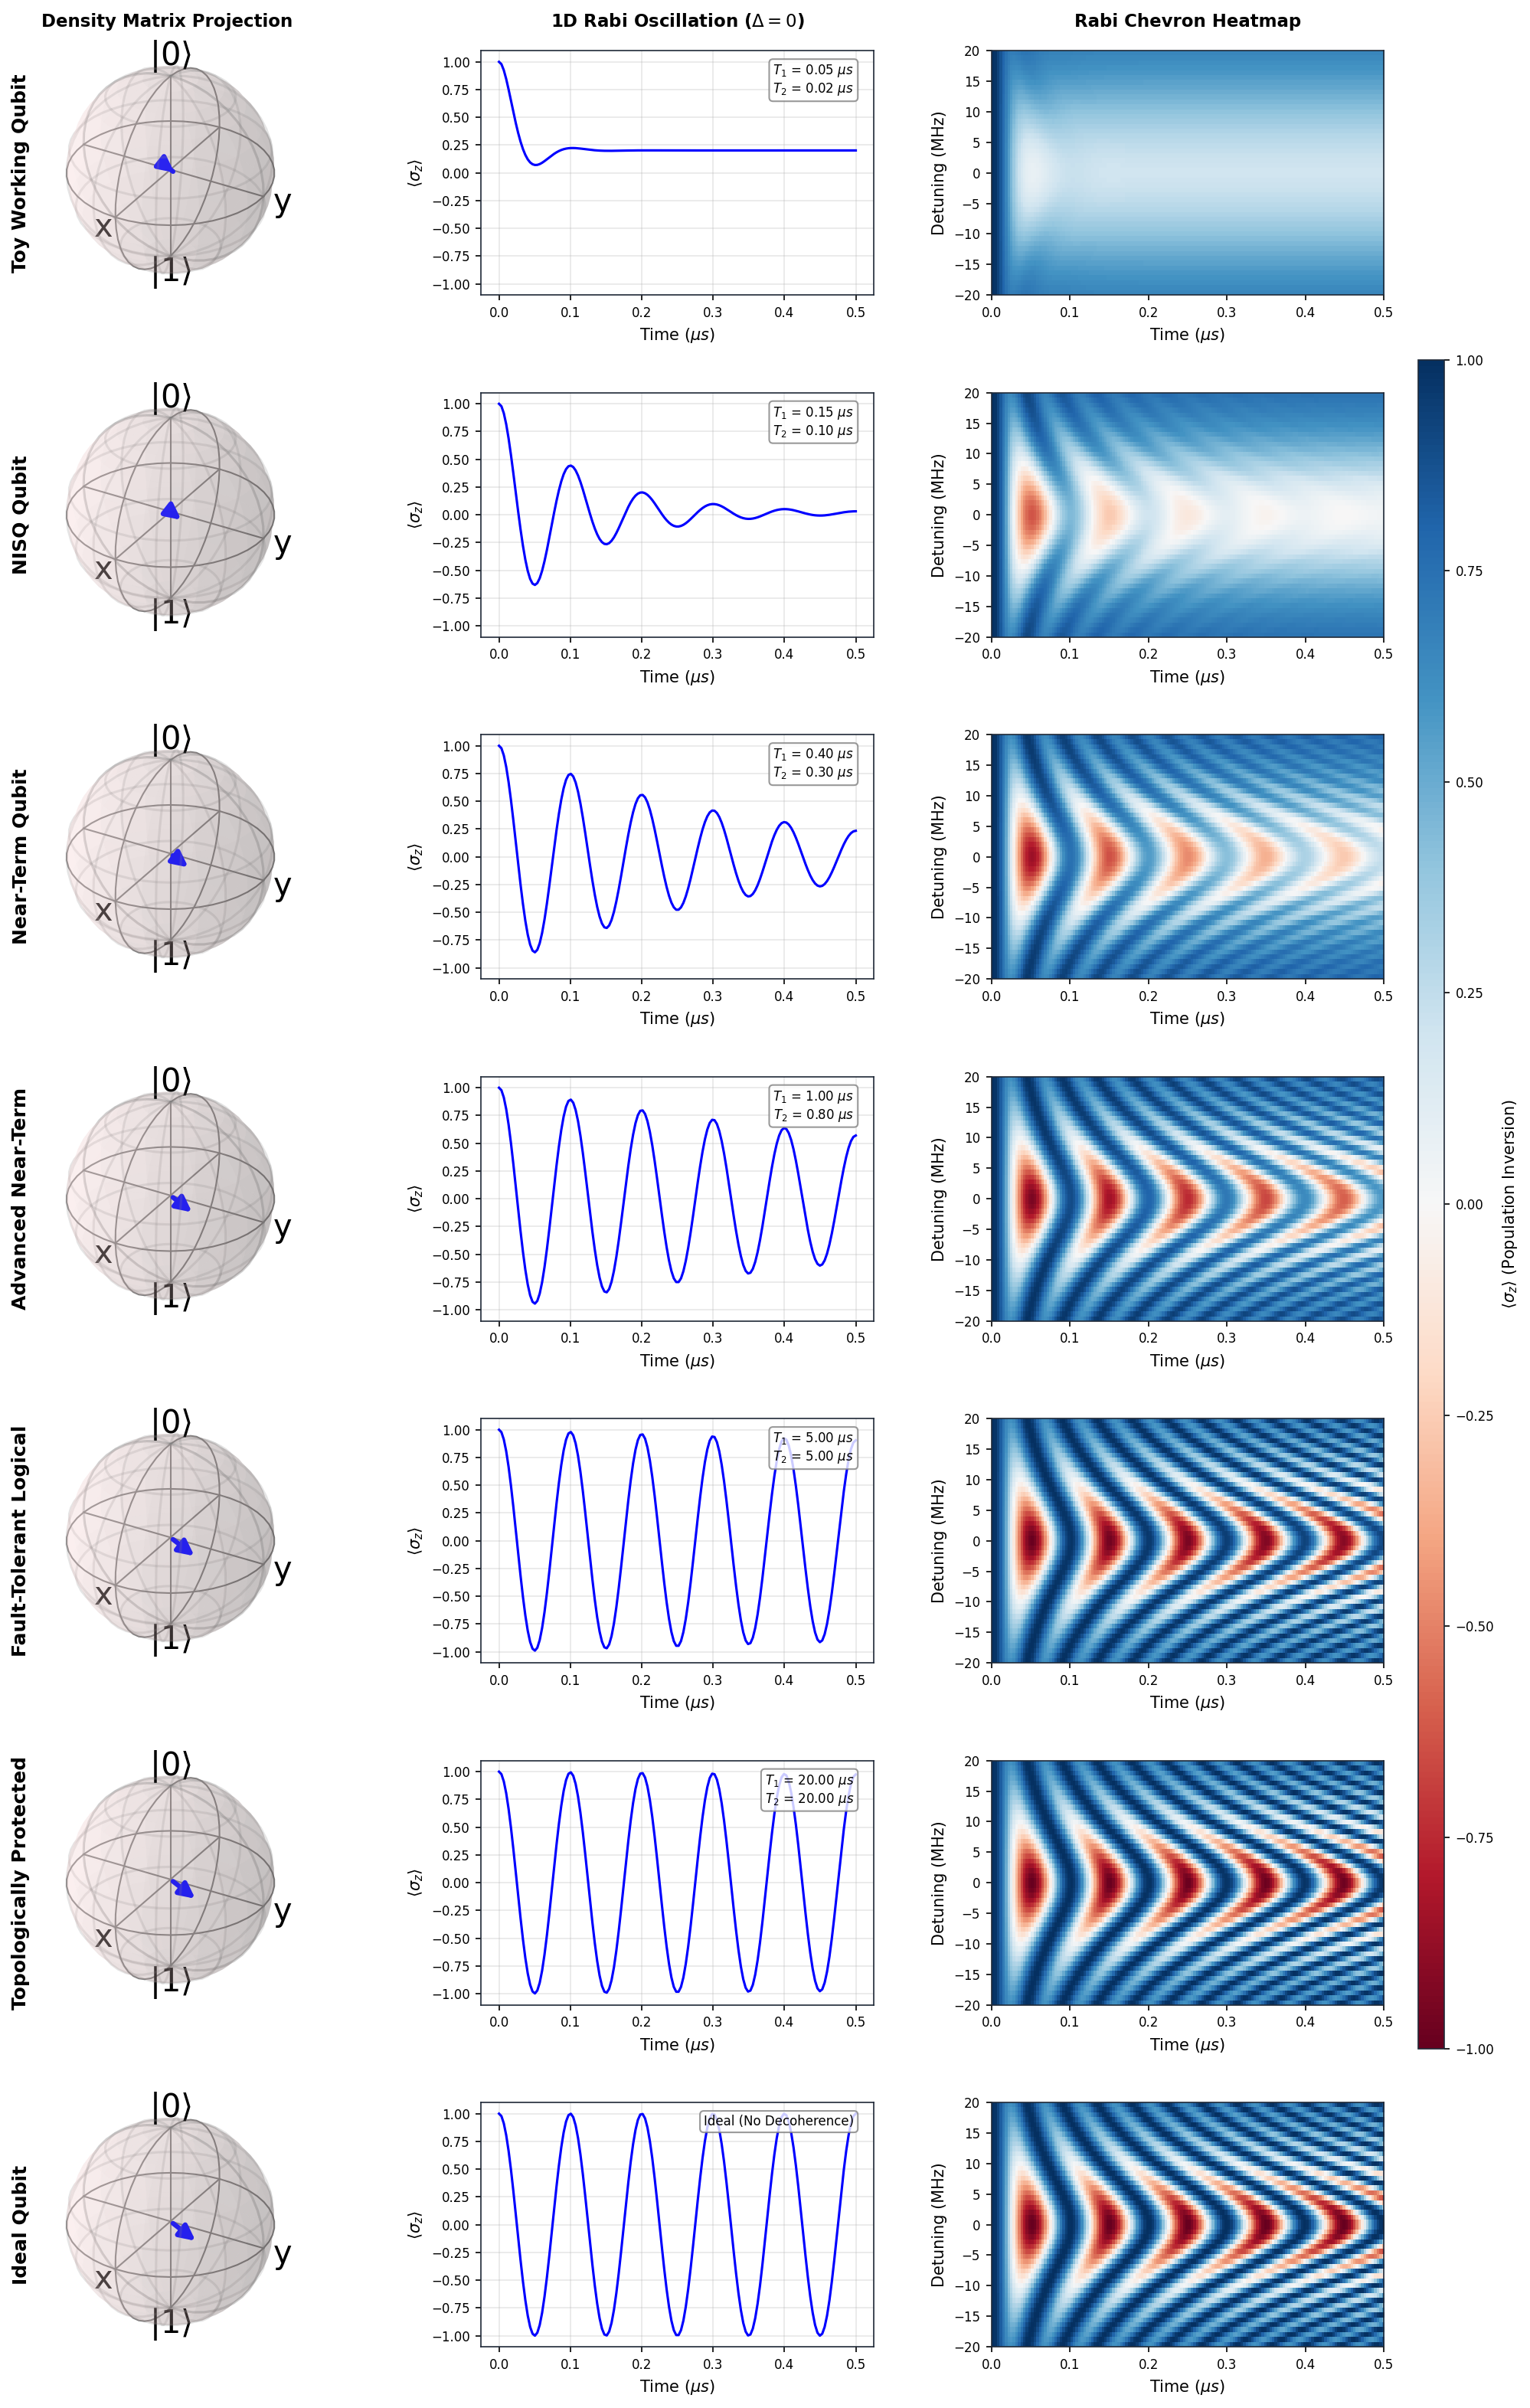

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from qutip import Bloch, Qobj, identity, sigmax, sigmay, sigmaz, basis, mesolve, expect, destroy

"""
This script simulates and visualizes density matrices, 1D Rabi oscillations,
and 2D Rabi heatmaps (Chevron plots) for seven distinct qubit classifications using QuTiP.
Fully labeled with axes, parameters, and Bloch sphere poles.
"""

# ==============================================================================
# CONTROL KNOBS & GLOBAL SETTINGS
# ==============================================================================
TARGET_THETA = np.pi / 2.5
TARGET_PHI = np.pi / 4.0
COLOR_PURE_BLUE = '#0000FF'
PLOT_DPI = 150
FONT_SANS_SERIF = ['Tahoma', 'DejaVu Sans']

# Physics Simulation Parameters
OMEGA = 2.0 * np.pi * 10.0       # Drive frequency (10 MHz)
TIME_STEPS = 150
TIME_MAX = 0.5                   # Maximum simulation time in microseconds
T_LIST = np.linspace(0, TIME_MAX, TIME_STEPS)

# Detuning parameters for the Heatmap (Chevron plot)
DETUNING_STEPS = 50
DETUNING_MAX = 2.0 * np.pi * 20.0
DETUNING_LIST = np.linspace(-DETUNING_MAX, DETUNING_MAX, DETUNING_STEPS)

# Decoherence Profiles for each classification (T1, T2 in microseconds)
CLASSIFICATIONS = [
    {"name": "Toy Working Qubit",       "radius": 0.15, "T1": 0.05,  "T2": 0.02},
    {"name": "NISQ Qubit",              "radius": 0.50, "T1": 0.15,  "T2": 0.10},
    {"name": "Near-Term Qubit",         "radius": 0.75, "T1": 0.40,  "T2": 0.30},
    {"name": "Advanced Near-Term",      "radius": 0.88, "T1": 1.00,  "T2": 0.80},
    {"name": "Fault-Tolerant Logical",  "radius": 0.96, "T1": 5.00,  "T2": 5.00},
    {"name": "Topologically Protected", "radius": 0.99, "T1": 20.0,  "T2": 20.0},
    {"name": "Ideal Qubit",             "radius": 1.00, "T1": np.inf,"T2": np.inf}
]

# ==============================================================================
# ENVIRONMENT CONFIGURATION
# ==============================================================================
mpl.rcParams['figure.dpi'] = PLOT_DPI
mpl.rcParams['font.sans-serif'] = FONT_SANS_SERIF
mpl.rcParams['savefig.dpi'] = PLOT_DPI
mpl.rcParams['font.size'] = 8

# ==============================================================================
# PHYSICS SIMULATION FUNCTIONS
# ==============================================================================
def get_collapse_operators(t1: float, t2: float) -> list:
    """Constructs the Lindblad collapse operators based on T1 and T2 times.

    Args:
        t1: The longitudinal relaxation time (T1) in microseconds.
        t2: The transverse relaxation time (T2) in microseconds.

    Returns:
        A list of QuTiP quantum objects representing the collapse operators.
    """
    c_ops = []
    sm = destroy(2)
    sz = sigmaz()

    if not np.isinf(t1):
        gamma1 = 1.0 / t1
        c_ops.append(np.sqrt(gamma1) * sm)

    if not np.isinf(t2):
        gamma1 = 0.0 if np.isinf(t1) else 1.0 / t1
        gamma2 = 1.0 / t2
        gamma_phi = gamma2 - (gamma1 / 2.0)

        if gamma_phi > 0:
            c_ops.append(np.sqrt(gamma_phi / 2.0) * sz)

    return c_ops

def simulate_rabi_dynamics(t1: float, t2: float, detuning: float) -> np.ndarray:
    """Solves the master equation for a driven qubit and returns sz expectation.

    Args:
        t1: Longitudinal relaxation time (T1) in microseconds.
        t2: Transverse relaxation time (T2) in microseconds.
        detuning: Detuning frequency Delta between drive and qubit.

    Returns:
        A NumPy array containing the expectation value of the sigma_z operator.
    """
    H = (detuning / 2.0) * sigmaz() + (OMEGA / 2.0) * sigmax()
    psi0 = basis(2, 0)
    c_ops = get_collapse_operators(t1, t2)
    result = mesolve(H, psi0, T_LIST, c_ops=c_ops, e_ops=[sigmaz()])
    return result.expect[0]

def generate_chevron_data(t1: float, t2: float) -> np.ndarray:
    """Generates the 2D data array for the Rabi heatmap across detunings.

    Args:
        t1: Longitudinal relaxation time (T1) in microseconds.
        t2: Transverse relaxation time (T2) in microseconds.

    Returns:
        A 2D NumPy array representing the Chevron plot data.
    """
    heatmap_data = np.zeros((DETUNING_STEPS, TIME_STEPS))
    for i, delta in enumerate(DETUNING_LIST):
        heatmap_data[i, :] = simulate_rabi_dynamics(t1, t2, delta)
    return heatmap_data

def generate_bloch_vector(theta: float, phi: float, radius: float) -> list:
    """Calculates Cartesian coordinates for a Bloch vector.

    Args:
        theta: Polar angle in radians.
        phi: Azimuthal angle in radians.
        radius: The length of the Bloch vector (purity).

    Returns:
        A list containing the [x, y, z] Cartesian coordinates.
    """
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    return [x, y, z]

# ==============================================================================
# VISUALIZATION EXECUTION
# ==============================================================================
def main():
    """Main execution block mapping the data to a comprehensive subplot grid."""
    num_classes = len(CLASSIFICATIONS)
    fig = plt.figure(figsize=(15, 3.0 * num_classes))

    for row, cls in enumerate(CLASSIFICATIONS):
        name = cls["name"]
        t1 = cls["T1"]
        t2 = cls["T2"]
        radius = cls["radius"]

        # -----------------------------------------------------------
        # Column 1: Static Density Matrix on Bloch Sphere
        # -----------------------------------------------------------
        ax1 = fig.add_subplot(num_classes, 3, (row * 3) + 1, projection='3d')
        vec = generate_bloch_vector(TARGET_THETA, TARGET_PHI, radius)
        rho_state = 0.5 * (identity(2) + vec[0]*sigmax() + vec[1]*sigmay() + vec[2]*sigmaz())

        bloch_sphere = Bloch(fig=fig, axes=ax1)
        bloch_sphere.vector_color = [COLOR_PURE_BLUE]
        bloch_sphere.add_states(rho_state)

        # Explicitly label the Bloch sphere axes and poles
        bloch_sphere.xlabel = ['x', '']
        bloch_sphere.ylabel = ['y', '']
        bloch_sphere.zlabel = [r'$|0\rangle$', r'$|1\rangle$']
        bloch_sphere.render()

        if row == 0:
            ax1.set_title("Density Matrix Projection", pad=15, fontsize=11, weight='bold')

        # Row label
        ax1.text2D(-0.1, 0.5, name, transform=ax1.transAxes,
                   rotation=90, va='center', ha='center', fontsize=12, weight='bold')

        # -----------------------------------------------------------
        # Column 2: 1D Time-Domain Rabi Oscillation
        # -----------------------------------------------------------
        ax2 = fig.add_subplot(num_classes, 3, (row * 3) + 2)
        sz_trace = simulate_rabi_dynamics(t1, t2, detuning=0.0)

        ax2.plot(T_LIST, sz_trace, color=COLOR_PURE_BLUE, linewidth=1.5)
        ax2.set_ylim(-1.1, 1.1)
        ax2.set_ylabel(r'$\langle \sigma_z \rangle$')
        ax2.set_xlabel(r'Time ($\mu s$)')
        ax2.grid(True, alpha=0.3)

        # Add parameter labels inside the plot
        if np.isinf(t1):
            param_text = "Ideal (No Decoherence)"
        else:
            param_text = f"$T_1$ = {t1:.2f} $\\mu s$\n$T_2$ = {t2:.2f} $\\mu s$"

        ax2.text(0.95, 0.95, param_text, transform=ax2.transAxes,
                 verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'))

        if row == 0:
            ax2.set_title(r"1D Rabi Oscillation ($\Delta = 0$)", pad=15, fontsize=11, weight='bold')

        # -----------------------------------------------------------
        # Column 3: 2D Rabi Heatmap (Chevron Plot)
        # -----------------------------------------------------------
        ax3 = fig.add_subplot(num_classes, 3, (row * 3) + 3)
        heatmap_data = generate_chevron_data(t1, t2)

        extent = [0, TIME_MAX, -DETUNING_MAX/(2*np.pi), DETUNING_MAX/(2*np.pi)]
        im = ax3.imshow(heatmap_data, aspect='auto', origin='lower',
                        extent=extent, cmap='RdBu', vmin=-1.0, vmax=1.0)

        ax3.set_ylabel(r'Detuning (MHz)')
        ax3.set_xlabel(r'Time ($\mu s$)')

        if row == 0:
            ax3.set_title("Rabi Chevron Heatmap", pad=15, fontsize=11, weight='bold')

    plt.tight_layout()
    plt.subplots_adjust(left=0.08, right=0.9, wspace=0.3, hspace=0.4)

    # Unified colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    fig.colorbar(im, cax=cbar_ax, label=r'$\langle \sigma_z \rangle$ (Population Inversion)')

    plt.show()

if __name__ == '__main__':
    main()